# SP2M Energy Demand — Hybrid LSTM + TFT Forecasting
---
**Objective:** Train a hybrid LSTM + Temporal Fusion Transformer model on 5-year augmented data, evaluate on held-out test set, and produce a stable 15-year forecast.

**Model:** LSTM encoder → Multi-Head Temporal Attention (TFT-style) → Gated Residual Network → Dense output

**Target:** `Total_Energy_MWh` (hourly)


In [1]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================
import os, gc, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# Plot configuration
plt.rcParams.update({
    'figure.figsize': (14, 5), 'figure.dpi': 100,
    'font.size': 11, 'axes.titlesize': 13,
    'figure.facecolor': 'white'
})
sns.set_style('whitegrid')

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
print(f"Device: {DEVICE}")


PyTorch: 2.7.1+cu118
CUDA: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Memory: 6.44 GB
Device: cuda


## 2. Load Augmented Data

In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================
FILEPATH = r'C:\Users\Oumaima\Desktop\Wiame\augmented_data.csv'

# Read with semicolon separator, handle mixed decimal formats
df = pd.read_csv(FILEPATH, sep=';', encoding='utf-8')

# Fix decimal separators: replace commas with dots in numeric columns
for col in df.columns:
    if col not in ['Timestamp', 'Season']:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse timestamp (DD/MM/YYYY HH:MM format)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')

# Sort by time
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")
print(f"Missing values: {df.isnull().sum().sum()}")
display(df.head())
display(df.dtypes)


Dataset shape: (43824, 17)
Date range: 2027-01-01 00:00:00 to 2031-12-31 23:00:00
Missing values: 0


,Timestamp,Mine_Benguerir_Energy_MWh,Mine_Louta_Energy_MWh,Benef_Benguerir_Energy_MWh,Benef_Louta_Energy_MWh,SAP_total_Energy_MWh,PAP_total_Energy_MWh,Drying_total_Energy_MWh,TSP_total_Energy_MWh,Total_Energy_MWh,Hour,Month,Year,DayOfWeek,Day,IsWeekend,Season
0,2027-01-01 00:00:00,2.359573,1.127174,8.312542,7.772313,31.279853,11.970456,2.458290,30.545559,96.805961,0,1,2027,4,1,0,HIVER
1,2027-01-01 01:00:00,2.320396,1.166605,8.005655,7.711008,31.157236,12.061558,2.455391,30.732091,97.561297,1,1,2027,4,1,0,HIVER
2,2027-01-01 02:00:00,2.335772,1.215028,7.770586,7.792527,31.220854,12.120124,2.502572,30.687492,98.223393,2,1,2027,4,1,0,HIVER
3,2027-01-01 03:00:00,2.375562,1.186591,7.885379,7.588318,31.336556,12.250137,2.486440,30.580566,97.780561,3,1,2027,4,1,0,HIVER
4,2027-01-01 04:00:00,2.320505,1.138140,8.013081,7.474764,31.751654,12.044545,2.477319,30.587643,96.657981,4,1,2027,4,1,0,HIVER


Timestamp                     datetime64[ns]
Mine_Benguerir_Energy_MWh            float64
Mine_Louta_Energy_MWh                float64
Benef_Benguerir_Energy_MWh           float64
Benef_Louta_Energy_MWh               float64
SAP_total_Energy_MWh                 float64
PAP_total_Energy_MWh                 float64
Drying_total_Energy_MWh              float64
TSP_total_Energy_MWh                 float64
Total_Energy_MWh                     float64
Hour                                   int64
Month                                  int64
Year                                   int64
DayOfWeek                              int64
Day                                    int64
IsWeekend                              int64
Season                                object
dtype: object

## 3. Data Preparation & Feature Engineering

In [3]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

# 3.1 Ensure time features exist
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['Year'] = df['Timestamp'].dt.year
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# 3.2 Cyclical encoding (captures periodic nature without discontinuities)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['DoW_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DoW_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# 3.3 Season encoding
season_map = {'HIVER': 0, 'PRINTEMPS': 1, 'ETE': 2, 'AUTOMNE': 3}
df['Season_enc'] = df['Season'].map(season_map).fillna(0).astype(int)

# 3.4 Target column
TARGET = 'Total_Energy_MWh'

# 3.5 Feature columns for the model
FEATURE_COLS = [
    TARGET,
    'Hour_sin', 'Hour_cos',
    'Month_sin', 'Month_cos',
    'DoW_sin', 'DoW_cos',
    'IsWeekend'
]
N_FEATURES = len(FEATURE_COLS)

print(f"Target: {TARGET}")
print(f"Features ({N_FEATURES}): {FEATURE_COLS}")
print(f"\nSample data:")
display(df[FEATURE_COLS].describe().round(4))


Target: Total_Energy_MWh
Features (8): ['Total_Energy_MWh', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DoW_sin', 'DoW_cos', 'IsWeekend']

Sample data:


,Total_Energy_MWh,Hour_sin,Hour_cos,Month_sin,Month_cos,DoW_sin,DoW_cos,IsWeekend
count,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000
mean,97.3388,-0.0000,-0.0000,-0.0049,-0.0021,-0.0002,0.0005,0.2859
std,6.3988,0.7071,0.7071,0.7057,0.7085,0.7072,0.7070,0.4518
min,79.8670,-1.0000,-1.0000,-1.0000,-1.0000,-0.9749,-0.9010,0.0000
25%,92.7006,-0.7071,-0.7071,-0.8660,-0.8660,-0.7818,-0.9010,0.0000
50%,96.9946,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.2225,0.0000
75%,101.8035,0.7071,0.7071,0.5000,0.8660,0.7818,0.6235,1.0000
max,116.5466,1.0000,1.0000,1.0000,1.0000,0.9749,1.0000,1.0000


In [4]:
# ============================================================
# 3.6 NORMALIZE DATA
# ============================================================
# Scale features to [0, 1] for better training
scaler = MinMaxScaler()
df_scaled = df[FEATURE_COLS].copy()
df_scaled[FEATURE_COLS] = scaler.fit_transform(df_scaled[FEATURE_COLS])

# Save scaler params for inverse transform of target
target_idx = FEATURE_COLS.index(TARGET)
target_min = scaler.data_min_[target_idx]
target_max = scaler.data_max_[target_idx]
target_range = scaler.data_range_[target_idx]

print(f"Target range: [{target_min:.2f}, {target_max:.2f}] MWh")
print(f"Scaled data shape: {df_scaled.shape}")
display(df_scaled.head())


Target range: [79.87, 116.55] MWh
Scaled data shape: (43824, 8)


,Total_Energy_MWh,Hour_sin,Hour_cos,Month_sin,Month_cos,DoW_sin,DoW_cos,IsWeekend
0,0.461809,0.500000,1.000000,0.75,0.933013,0.277479,0.0,0.0
1,0.482401,0.629410,0.982963,0.75,0.933013,0.277479,0.0,0.0
2,0.500452,0.750000,0.933013,0.75,0.933013,0.277479,0.0,0.0
3,0.488379,0.853553,0.853553,0.75,0.933013,0.277479,0.0,0.0
4,0.457774,0.933013,0.750000,0.75,0.933013,0.277479,0.0,0.0


## 4. Train / Validation / Test Split
**Time-based split** — no shuffling, no leakage, chronological order respected.
- Train: 70% | Validation: 15% | Test: 15%


In [5]:
# ============================================================
# 4. TIME-BASED SPLIT (70 / 15 / 15)
# ============================================================
n = len(df_scaled)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = df_scaled.values[:train_end]
val_data = df_scaled.values[train_end:val_end]
test_data = df_scaled.values[val_end:]

train_timestamps = df['Timestamp'].values[:train_end]
val_timestamps = df['Timestamp'].values[train_end:val_end]
test_timestamps = df['Timestamp'].values[val_end:]

print(f"Total samples: {n}")
print(f"Train: {len(train_data)} ({len(train_data)/n*100:.1f}%)  "
      f"[{pd.Timestamp(train_timestamps[0]).strftime('%Y-%m-%d')} → "
      f"{pd.Timestamp(train_timestamps[-1]).strftime('%Y-%m-%d')}]")
print(f"Val:   {len(val_data)} ({len(val_data)/n*100:.1f}%)  "
      f"[{pd.Timestamp(val_timestamps[0]).strftime('%Y-%m-%d')} → "
      f"{pd.Timestamp(val_timestamps[-1]).strftime('%Y-%m-%d')}]")
print(f"Test:  {len(test_data)} ({len(test_data)/n*100:.1f}%)  "
      f"[{pd.Timestamp(test_timestamps[0]).strftime('%Y-%m-%d')} → "
      f"{pd.Timestamp(test_timestamps[-1]).strftime('%Y-%m-%d')}]")


Total samples: 43824
Train: 30676 (70.0%)  [2027-01-01 → 2030-07-02]
Val:   6574 (15.0%)  [2030-07-02 → 2031-04-02]
Test:  6574 (15.0%)  [2031-04-02 → 2031-12-31]


In [6]:
# ============================================================
# 5. PYTORCH DATASET & DATALOADER
# ============================================================
SEQ_LEN = 168    # Input: past 7 days (168 hours)
PRED_LEN = 1     # Output: next 1 hour
BATCH_SIZE = 12    #256

class TimeSeriesDataset(Dataset):
    """Sliding window dataset for time series forecasting."""
    def __init__(self, data, seq_len=SEQ_LEN, pred_len=PRED_LEN):
        self.data = torch.FloatTensor(data)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]          # (seq_len, n_features)
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len, 0]  # target only
        return x, y

# Create datasets
train_dataset = TimeSeriesDataset(train_data)
val_dataset = TimeSeriesDataset(val_data)
test_dataset = TimeSeriesDataset(test_data)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Sequence length: {SEQ_LEN} hours ({SEQ_LEN//24} days)")
print(f"Prediction length: {PRED_LEN} hour(s)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
print(f"Input shape per sample: ({SEQ_LEN}, {N_FEATURES})")


Sequence length: 168 hours (7 days)
Prediction length: 1 hour(s)
Batch size: 12
Train batches: 2542, Val batches: 534, Test batches: 534
Input shape per sample: (168, 8)


## 5. Model Design — Hybrid LSTM + TFT
Architecture:
1. **LSTM Encoder**: Captures temporal dependencies (2 layers, bidirectional)
2. **Gated Residual Network (GRN)**: Controls information flow (from TFT)
3. **Multi-Head Temporal Attention**: Focuses on important time steps (from TFT)
4. **Dense Output**: Final prediction


In [7]:
# ============================================================
# 5.1 GATED RESIDUAL NETWORK (GRN) — from TFT
# ============================================================
class GatedResidualNetwork(nn.Module):
    """GRN from Temporal Fusion Transformer.
    Controls information flow with gating mechanism."""
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.gate = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
        self.layer_norm = nn.LayerNorm(output_dim)
        # Skip connection projection if dimensions differ
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        h = self.elu(self.fc1(x))
        h = self.dropout(h)
        out = self.fc2(h)
        gate = self.sigmoid(self.gate(h))
        out = gate * out + (1 - gate) * residual
        out = self.layer_norm(out)
        return out

print("GatedResidualNetwork defined.")


GatedResidualNetwork defined.


In [8]:
# ============================================================
# 5.2 TEMPORAL MULTI-HEAD ATTENTION — from TFT
# ============================================================
class TemporalAttention(nn.Module):
    """Multi-head self-attention for temporal sequences."""
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Self-attention with residual connection
        attn_out, attn_weights = self.attention(x, x, x)
        out = self.layer_norm(x + self.dropout(attn_out))
        return out, attn_weights

print("TemporalAttention defined.")


TemporalAttention defined.


In [9]:
# ============================================================
# 5.3 HYBRID LSTM + TFT MODEL
# ============================================================
class HybridLSTM_TFT(nn.Module):
    """
    Hybrid model combining LSTM encoder with TFT components.

    Architecture:
    Input → Feature Projection → LSTM Encoder → GRN →
    Temporal Attention → GRN → Dense → Output
    """
    def __init__(self, n_features, d_model=64, lstm_layers=2,
                 n_heads=4, dropout=0.15, pred_len=1):
        super().__init__()
        self.pred_len = pred_len
        self.d_model = d_model

        # 1. Feature projection
        self.input_projection = nn.Linear(n_features, d_model)

        # 2. LSTM encoder (bidirectional for richer representations)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0,
            bidirectional=False   # Keep unidirectional for forecasting
        )

        # 3. Post-LSTM GRN
        self.grn_post_lstm = GatedResidualNetwork(d_model, d_model * 2, d_model, dropout)

        # 4. Temporal attention (TFT-style)
        self.temporal_attention = TemporalAttention(d_model, n_heads, dropout)

        # 5. Post-attention GRN
        self.grn_post_attn = GatedResidualNetwork(d_model, d_model * 2, d_model, dropout)

        # 6. Output layers
        self.output_fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, pred_len)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        batch_size = x.size(0)

        # 1. Project input features
        h = self.input_projection(x)           # (batch, seq, d_model)

        # 2. LSTM encoding
        lstm_out, (h_n, c_n) = self.lstm(h)    # (batch, seq, d_model)

        # 3. GRN after LSTM
        grn_out = self.grn_post_lstm(lstm_out)  # (batch, seq, d_model)

        # 4. Temporal attention
        attn_out, attn_weights = self.temporal_attention(grn_out)  # (batch, seq, d_model)

        # 5. GRN after attention
        refined = self.grn_post_attn(attn_out)  # (batch, seq, d_model)

        # 6. Use last timestep for prediction
        last = refined[:, -1, :]                # (batch, d_model)

        # 7. Output
        out = self.output_fc(last)              # (batch, pred_len)
        return out, attn_weights

# Instantiate model
model = HybridLSTM_TFT(
    n_features=N_FEATURES,
    d_model=64,
    lstm_layers=2,
    n_heads=4,
    dropout=0.15,
    pred_len=PRED_LEN
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: HybridLSTM_TFT")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)


Model: HybridLSTM_TFT
Total parameters: 135,937
Trainable parameters: 135,937

Model architecture:
HybridLSTM_TFT(
  (input_projection): Linear(in_features=8, out_features=64, bias=True)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.15)
  (grn_post_lstm): GatedResidualNetwork(
    (fc1): Linear(in_features=64, out_features=128, bias=True)
    (elu): ELU(alpha=1.0)
    (fc2): Linear(in_features=128, out_features=64, bias=True)
    (dropout): Dropout(p=0.15, inplace=False)
    (gate): Linear(in_features=128, out_features=64, bias=True)
    (sigmoid): Sigmoid()
    (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (skip): Identity()
  )
  (temporal_attention): TemporalAttention(
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    )
    (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (grn_post_attn)

## 6. Loss, Optimizer & Scheduler

In [10]:
# ============================================================
# 6. LOSS, OPTIMIZER, SCHEDULER, EARLY STOPPING
# ============================================================

# Huber Loss — robust to outliers
criterion = nn.HuberLoss(delta=1.0)

# Adam optimizer
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# Learning rate scheduler — ReduceLROnPlateau (reduce on validation loss plateau)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

# Early stopping config
PATIENCE = 15
N_EPOCHS = 100
BEST_MODEL_PATH = r'C:\Users\Oumaima\Desktop\Wiame\best_model.pth'

print(f"Loss: HuberLoss (delta=1.0)")
print(f"Optimizer: Adam (lr={LEARNING_RATE}, weight_decay=1e-5)")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"Early stopping: patience={PATIENCE}")
print(f"Max epochs: {N_EPOCHS}")


Loss: HuberLoss (delta=1.0)
Optimizer: Adam (lr=0.001, weight_decay=1e-5)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Early stopping: patience=15
Max epochs: 100


## 7. Training Loop

In [11]:
# ============================================================
# 7. TRAINING LOOP WITH MEMORY MANAGEMENT
# ============================================================
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    n_batches = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred, _ = model(X_batch)
        loss = criterion(pred.squeeze(), y_batch.squeeze())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

        # Memory management
        del X_batch, y_batch, pred, loss
    gc.collect()
    torch.cuda.empty_cache()
    return total_loss / n_batches


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss = 0
    n_batches = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        pred, _ = model(X_batch)
        loss = criterion(pred.squeeze(), y_batch.squeeze())

        total_loss += loss.item()
        n_batches += 1

        del X_batch, y_batch, pred, loss
    gc.collect()
    torch.cuda.empty_cache()
    return total_loss / n_batches

print("Training and evaluation functions defined.")


Training and evaluation functions defined.


In [12]:
# ============================================================
# 7.2 RUN TRAINING
# ============================================================
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
start_time = time.time()

print(f"{'Epoch':>5} | {'Train Loss':>11} | {'Val Loss':>11} | {'LR':>10} | {'Status':>10}")
print("-" * 65)

for epoch in range(1, N_EPOCHS + 1):
    epoch_start = time.time()

    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    # Validate
    val_loss = eval_epoch(model, val_loader, criterion, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Early stopping check
    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        status = "★ saved"
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"{epoch:5d} | {train_loss:.6f}   | {val_loss:.6f}   | {current_lr:.2e} | STOPPED")
            print(f"\nEarly stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
            break

    if epoch % 5 == 0 or epoch <= 3 or status:
        print(f"{epoch:5d} | {train_loss:.6f}   | {val_loss:.6f}   | {current_lr:.2e} | {status}")

    # Memory cleanup after each epoch
    gc.collect()
    torch.cuda.empty_cache()

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")
print(f"Best validation loss: {best_val_loss:.6f}")


Epoch |  Train Loss |    Val Loss |         LR |     Status
-----------------------------------------------------------------
    1 | 0.004102   | 0.017314   | 1.00e-03 | ★ saved
    2 | 0.002219   | 0.018456   | 1.00e-03 | 
    3 | 0.002120   | 0.018890   | 1.00e-03 | 
    5 | 0.002321   | 0.018627   | 1.00e-03 | 
    6 | 0.002500   | 0.017306   | 1.00e-03 | ★ saved
    7 | 0.002392   | 0.016502   | 1.00e-03 | ★ saved
    8 | 0.002475   | 0.015696   | 1.00e-03 | ★ saved
   10 | 0.002022   | 0.017484   | 1.00e-03 | 
   14 | 0.001776   | 0.015664   | 1.00e-03 | ★ saved
   15 | 0.001562   | 0.011535   | 1.00e-03 | ★ saved
   16 | 0.001347   | 0.010750   | 1.00e-03 | ★ saved
   17 | 0.001198   | 0.009167   | 1.00e-03 | ★ saved
   18 | 0.000964   | 0.006671   | 1.00e-03 | ★ saved
   19 | 0.000861   | 0.006387   | 1.00e-03 | ★ saved
   20 | 0.000784   | 0.005332   | 1.00e-03 | ★ saved
   21 | 0.000743   | 0.004933   | 1.00e-03 | ★ saved
   22 | 0.000697   | 0.004846   | 1.00e-03 | ★ saved
 

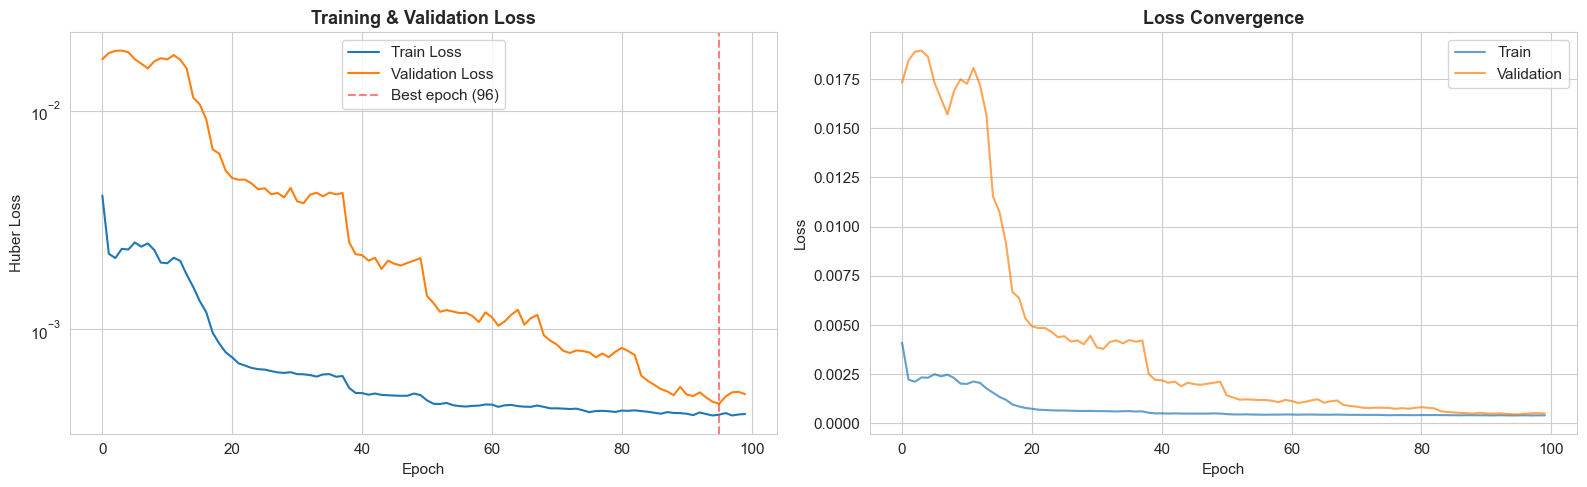

Training curves saved.


In [13]:
# ============================================================
# 7.3 TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', linewidth=1.5)
axes[0].plot(val_losses, label='Validation Loss', linewidth=1.5)
axes[0].axvline(x=np.argmin(val_losses), color='red', linestyle='--', alpha=0.5, label=f'Best epoch ({np.argmin(val_losses)+1})')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()
axes[0].set_yscale('log')

# Learning rate (approximate from loss plateau patterns)
axes[1].plot(train_losses, label='Train', alpha=0.7)
axes[1].plot(val_losses, label='Validation', alpha=0.7)
axes[1].set_title('Loss Convergence', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\Oumaima\Desktop\Wiame\Resulta\training_curves_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")


## 8. Final Evaluation on Test Set

In [16]:
# ============================================================
# 8. EVALUATE ON TEST SET
# ============================================================
# Load best model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

# Collect all predictions
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred, _ = model(X_batch)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y_batch.numpy())
        del X_batch, pred
    gc.collect()
    torch.cuda.empty_cache()

# Concatenate
preds_scaled = np.concatenate(all_preds, axis=0).flatten()
targets_scaled = np.concatenate(all_targets, axis=0).flatten()

# Inverse transform to original scale
preds_original = preds_scaled * target_range + target_min
targets_original = targets_scaled * target_range + target_min

# Compute metrics
mae = np.mean(np.abs(preds_original - targets_original))
rmse = np.sqrt(np.mean((preds_original - targets_original)**2))
# MAPE (avoid division by zero)
mask = targets_original > 0
mape = np.mean(np.abs((targets_original[mask] - preds_original[mask]) / targets_original[mask])) * 100

# R² score
ss_res = np.sum((targets_original - preds_original) ** 2)
ss_tot = np.sum((targets_original - np.mean(targets_original)) ** 2)
r2 = 1 - (ss_res / (ss_tot + 1e-8))


print("=" * 50)
print("  TEST SET EVALUATION")
print("=" * 50)
print(f"  MAE:  {mae:.4f} MWh")
print(f"  RMSE: {rmse:.4f} MWh")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")
print(f"  Samples: {len(preds_original)}")
print("=" * 50)


  TEST SET EVALUATION
  MAE:  0.8854 MWh
  RMSE: 1.1478 MWh
  MAPE: 0.88%
  R²:   0.9667
  Samples: 6406


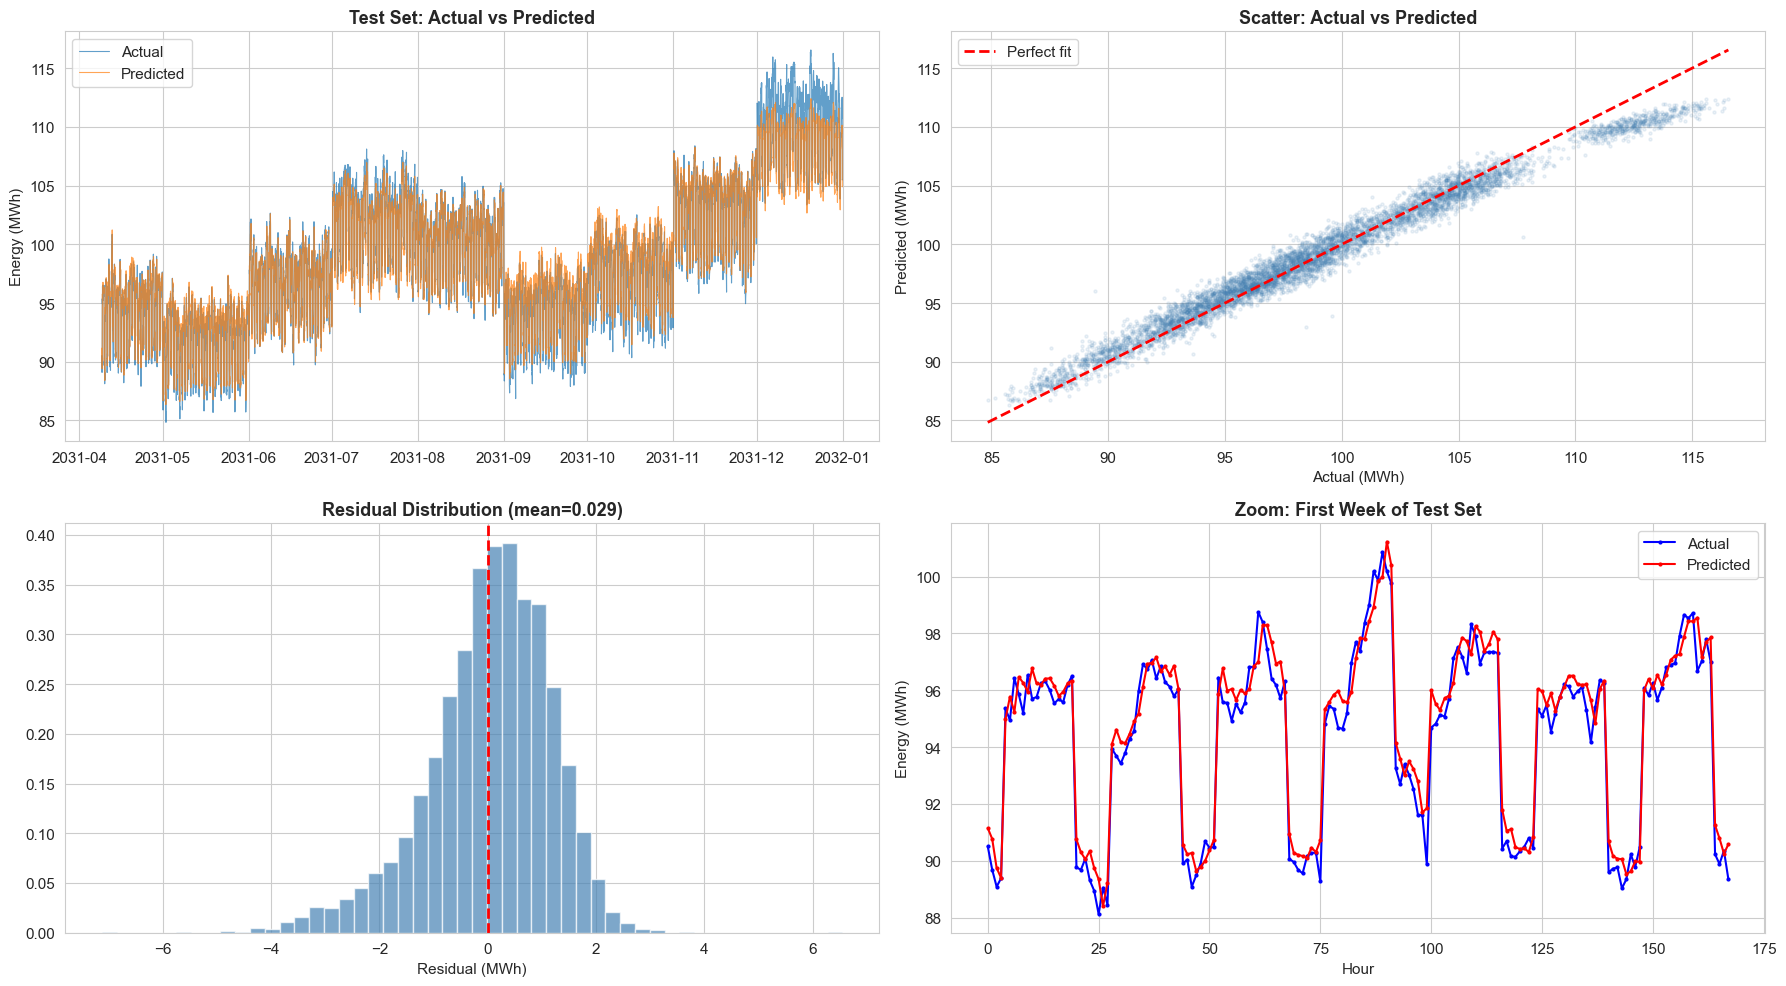

In [17]:
# ============================================================
# 8.2 TEST SET VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. Predicted vs Actual time series
test_ts = test_timestamps[SEQ_LEN:SEQ_LEN+len(preds_original)]
axes[0, 0].plot(test_ts, targets_original, label='Actual', alpha=0.7, linewidth=0.8)
axes[0, 0].plot(test_ts, preds_original, label='Predicted', alpha=0.7, linewidth=0.8)
axes[0, 0].set_title('Test Set: Actual vs Predicted', fontweight='bold')
axes[0, 0].set_ylabel('Energy (MWh)')
axes[0, 0].legend()

# 2. Scatter plot
axes[0, 1].scatter(targets_original, preds_original, alpha=0.1, s=5, color='steelblue')
min_val = min(targets_original.min(), preds_original.min())
max_val = max(targets_original.max(), preds_original.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
axes[0, 1].set_title('Scatter: Actual vs Predicted', fontweight='bold')
axes[0, 1].set_xlabel('Actual (MWh)')
axes[0, 1].set_ylabel('Predicted (MWh)')
axes[0, 1].legend()

# 3. Residuals
residuals = preds_original - targets_original
axes[1, 0].hist(residuals, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title(f'Residual Distribution (mean={residuals.mean():.3f})', fontweight='bold')
axes[1, 0].set_xlabel('Residual (MWh)')

# 4. 1-week zoom
week_len = 168
axes[1, 1].plot(range(week_len), targets_original[:week_len], 'b-o', markersize=2, label='Actual')
axes[1, 1].plot(range(week_len), preds_original[:week_len], 'r-o', markersize=2, label='Predicted')
axes[1, 1].set_title('Zoom: First Week of Test Set', fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Energy (MWh)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\Oumaima\Desktop\Wiame\Resulta\test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Long-Term Forecasting (15 Years)
Autoregressive forecasting: predict one hour at a time, feed prediction back as input.
Time features (hour, month, day-of-week) are known future covariates.


In [18]:
# ============================================================
# 9. 15-YEAR AUTOREGRESSIVE FORECAST
# ============================================================

# Generate future timestamps (2032-01-01 to 2046-12-31)
future_start = pd.Timestamp('2032-01-01 00:00:00')
future_end = pd.Timestamp('2046-12-31 23:00:00')
future_timestamps = pd.date_range(start=future_start, end=future_end, freq='h')
n_future = len(future_timestamps)

print(f"Forecasting {n_future} hours ({n_future/8760:.1f} years)")
print(f"Period: {future_start} to {future_end}")

# Prepare known future covariates (cyclical time features)
future_hour_sin = np.sin(2 * np.pi * future_timestamps.hour / 24)
future_hour_cos = np.cos(2 * np.pi * future_timestamps.hour / 24)
future_month_sin = np.sin(2 * np.pi * future_timestamps.month / 12)
future_month_cos = np.cos(2 * np.pi * future_timestamps.month / 12)
future_dow_sin = np.sin(2 * np.pi * future_timestamps.dayofweek / 7)
future_dow_cos = np.cos(2 * np.pi * future_timestamps.dayofweek / 7)
future_isweekend = (future_timestamps.dayofweek >= 5).astype(float)

# Stack known covariates: [hour_sin, hour_cos, month_sin, month_cos, dow_sin, dow_cos, isweekend]
# These correspond to FEATURE_COLS[1:] (index 1 to 7), normalized to [0,1]
future_covariates = np.column_stack([
    future_hour_sin, future_hour_cos,
    future_month_sin, future_month_cos,
    future_dow_sin, future_dow_cos,
    future_isweekend
])

# Normalize covariates using the same scaler ranges
for i in range(future_covariates.shape[1]):
    feat_idx = i + 1  # Skip target at index 0
    fmin = scaler.data_min_[feat_idx]
    fmax = scaler.data_max_[feat_idx]
    frange = fmax - fmin
    if frange > 0:
        future_covariates[:, i] = (future_covariates[:, i] - fmin) / frange
    else:
        future_covariates[:, i] = 0.0

print(f"Future covariates shape: {future_covariates.shape}")


Forecasting 131496 hours (15.0 years)
Period: 2032-01-01 00:00:00 to 2046-12-31 23:00:00
Future covariates shape: (131496, 7)


In [19]:
# ============================================================
# 9.2 AUTOREGRESSIVE FORECASTING LOOP
# ============================================================
model.eval()

# Initialize with the last SEQ_LEN observations from the full dataset
seed_data = df_scaled.values[-SEQ_LEN:].copy()  # (SEQ_LEN, N_FEATURES)
input_window = seed_data.copy()

forecast_scaled = []
forecast_batch_size = 12  # Process in batches to show progress (720h = 30 days)

print(f"Starting autoregressive forecast ({n_future} steps)...")
print(f"Seed window from: {df['Timestamp'].iloc[-SEQ_LEN]} to {df['Timestamp'].iloc[-1]}")

start_time = time.time()

with torch.no_grad():
    for i in range(n_future):
        # Prepare input tensor
        x = torch.FloatTensor(input_window).unsqueeze(0).to(DEVICE)  # (1, SEQ_LEN, N_FEATURES)

        # Predict
        pred, _ = model(x)
        pred_val = pred.cpu().item()

        # Clip prediction to valid range [0, 1] for scaled data
        pred_val = np.clip(pred_val, 0.0, 1.0)

        forecast_scaled.append(pred_val)

        # Construct next step's feature vector
        next_features = np.zeros(N_FEATURES)
        next_features[0] = pred_val                    # Predicted target (scaled)
        next_features[1:] = future_covariates[i]       # Known covariates

        # Slide window: remove oldest, append newest
        input_window = np.vstack([input_window[1:], next_features.reshape(1, -1)])

        # Memory cleanup periodically
        if (i + 1) % forecast_batch_size == 0:
            pct = (i + 1) / n_future * 100
            elapsed = time.time() - start_time
            remaining = elapsed / (i + 1) * (n_future - i - 1)
            print(f"  Progress: {pct:.1f}% ({i+1}/{n_future}) | "
                  f"Elapsed: {elapsed/60:.1f}min | ETA: {remaining/60:.1f}min")
            del x, pred
            gc.collect()
            torch.cuda.empty_cache()

forecast_scaled = np.array(forecast_scaled)
elapsed = time.time() - start_time
print(f"\nForecast completed in {elapsed/60:.1f} minutes")

# Inverse transform
forecast_original = forecast_scaled * target_range + target_min

# Basic sanity check
print(f"\nForecast statistics:")
print(f"  Mean:  {forecast_original.mean():.2f} MWh")
print(f"  Std:   {forecast_original.std():.2f} MWh")
print(f"  Min:   {forecast_original.min():.2f} MWh")
print(f"  Max:   {forecast_original.max():.2f} MWh")


Starting autoregressive forecast (131496 steps)...
Seed window from: 2031-12-25 00:00:00 to 2031-12-31 23:00:00
  Progress: 0.0% (12/131496) | Elapsed: 0.0min | ETA: 17.2min
  Progress: 0.0% (24/131496) | Elapsed: 0.0min | ETA: 29.4min
  Progress: 0.0% (36/131496) | Elapsed: 0.0min | ETA: 30.6min
  Progress: 0.0% (48/131496) | Elapsed: 0.0min | ETA: 30.4min
  Progress: 0.0% (60/131496) | Elapsed: 0.0min | ETA: 30.4min
  Progress: 0.1% (72/131496) | Elapsed: 0.0min | ETA: 31.0min
  Progress: 0.1% (84/131496) | Elapsed: 0.0min | ETA: 32.2min
  Progress: 0.1% (96/131496) | Elapsed: 0.0min | ETA: 32.4min
  Progress: 0.1% (108/131496) | Elapsed: 0.0min | ETA: 32.8min
  Progress: 0.1% (120/131496) | Elapsed: 0.0min | ETA: 33.0min
  Progress: 0.1% (132/131496) | Elapsed: 0.0min | ETA: 33.3min
  Progress: 0.1% (144/131496) | Elapsed: 0.0min | ETA: 33.3min
  Progress: 0.1% (156/131496) | Elapsed: 0.0min | ETA: 33.8min
  Progress: 0.1% (168/131496) | Elapsed: 0.0min | ETA: 33.9min
  Progress: 0.

## 10. Visualization

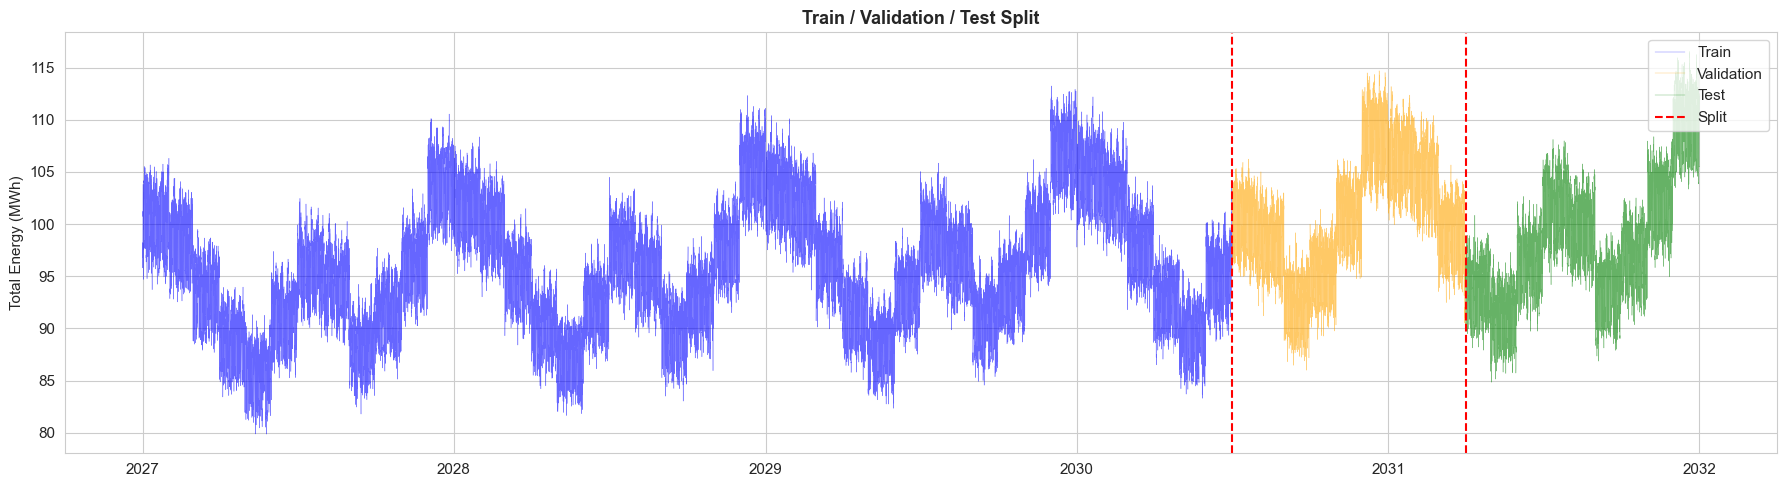

In [20]:
# ============================================================
# 10.1 TRAIN / VAL / TEST SPLIT VISUALIZATION
# ============================================================
fig, ax = plt.subplots(figsize=(18, 5))

# Original data
target_original = df[TARGET].values
ax.plot(df['Timestamp'].values[:train_end], target_original[:train_end],
        label='Train', alpha=0.6, linewidth=0.3, color='blue')
ax.plot(df['Timestamp'].values[train_end:val_end], target_original[train_end:val_end],
        label='Validation', alpha=0.6, linewidth=0.3, color='orange')
ax.plot(df['Timestamp'].values[val_end:], target_original[val_end:],
        label='Test', alpha=0.6, linewidth=0.3, color='green')

# Add split boundaries
ax.axvline(df['Timestamp'].iloc[train_end], color='red', linestyle='--', linewidth=1.5, label='Split')
ax.axvline(df['Timestamp'].iloc[val_end], color='red', linestyle='--', linewidth=1.5)

ax.set_title('Train / Validation / Test Split', fontweight='bold')
ax.set_ylabel('Total Energy (MWh)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(r'C:\Users\Oumaima\Desktop\Wiame\Resulta\train_val_test_split.png', dpi=150, bbox_inches='tight')
plt.show()


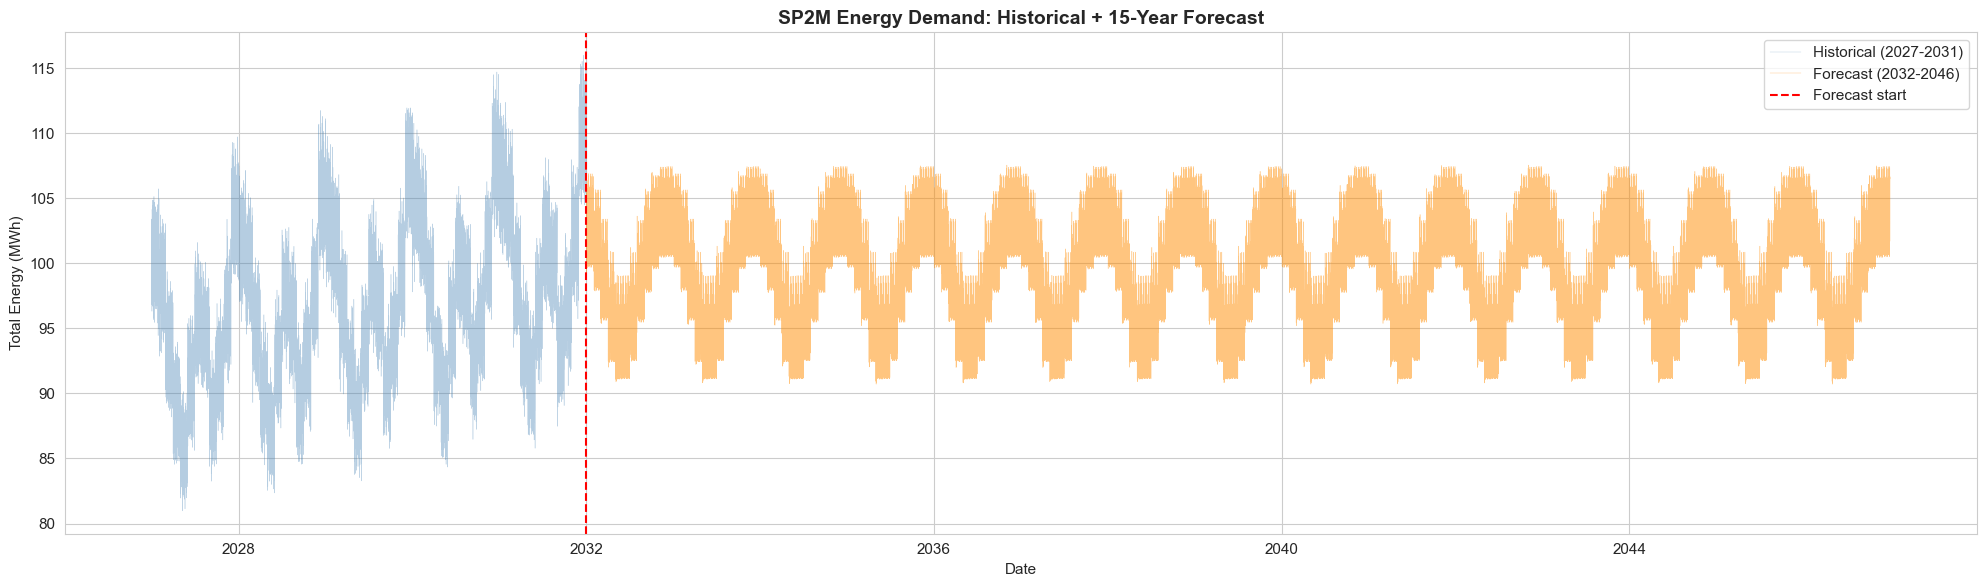

In [21]:
# ============================================================
# 10.2 FULL TIMELINE: HISTORICAL + 15-YEAR FORECAST
# ============================================================
fig, ax = plt.subplots(figsize=(20, 6))

# Historical (subsampled for performance)
hist_step = 6  # Plot every 6th hour
ax.plot(df['Timestamp'].values[::hist_step], target_original[::hist_step],
        label='Historical (2027-2031)', alpha=0.4, linewidth=0.3, color='steelblue')

# Forecast
fc_step = 6
ax.plot(future_timestamps[::fc_step], forecast_original[::fc_step],
        label='Forecast (2032-2046)', alpha=0.5, linewidth=0.3, color='darkorange')

ax.axvline(pd.Timestamp('2032-01-01'), color='red', linestyle='--', linewidth=1.5, label='Forecast start')
ax.set_title('SP2M Energy Demand: Historical + 15-Year Forecast', fontweight='bold', fontsize=14)
ax.set_ylabel('Total Energy (MWh)')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Users\Oumaima\Desktop\Wiame\Resulta\full_forecast_15years.png', dpi=150, bbox_inches='tight')
plt.show()


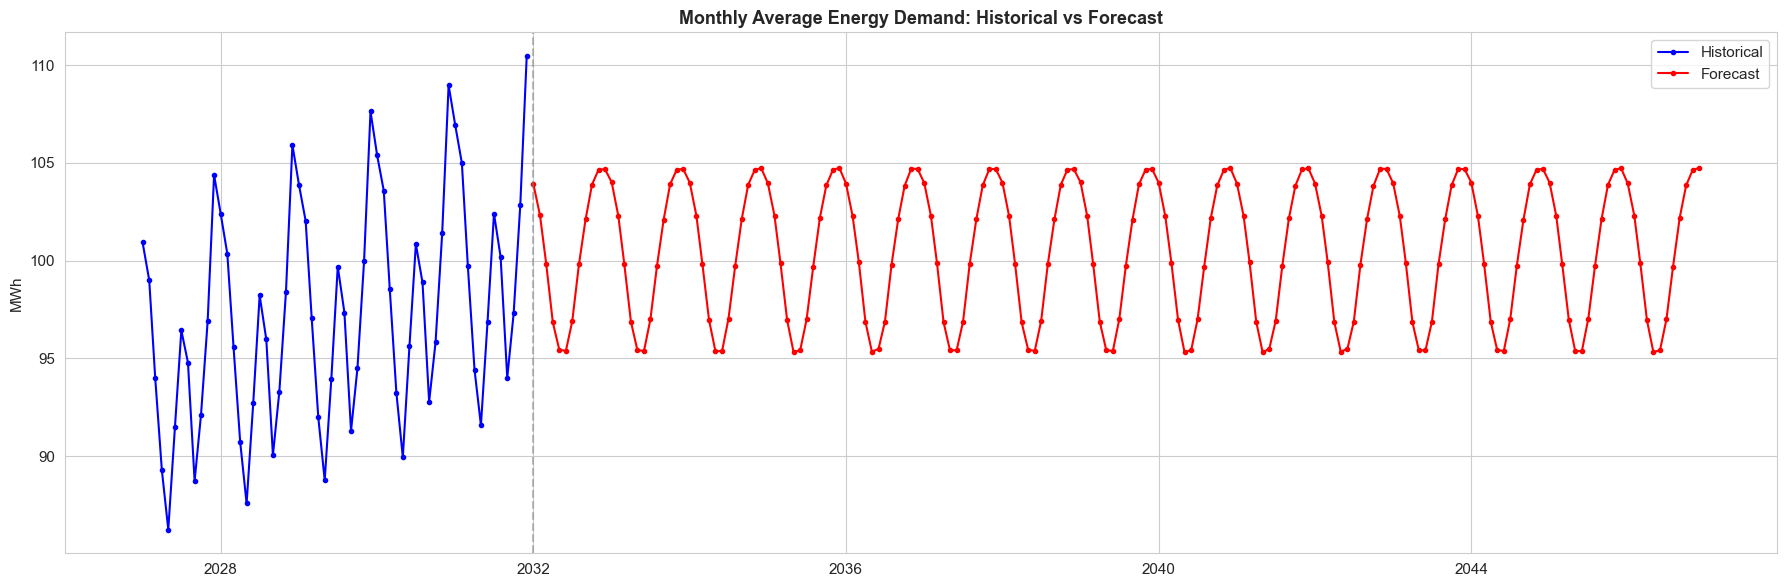

In [22]:
# ============================================================
# 10.3 MONTHLY AVERAGES — HISTORICAL vs FORECAST
# ============================================================
# Historical monthly
hist_monthly = df.groupby(df['Timestamp'].dt.to_period('M'))[TARGET].mean()
hist_monthly.index = hist_monthly.index.to_timestamp()

# Forecast monthly
fc_df = pd.DataFrame({'Timestamp': future_timestamps, 'Forecast': forecast_original})
fc_monthly = fc_df.groupby(fc_df['Timestamp'].dt.to_period('M'))['Forecast'].mean()
fc_monthly.index = fc_monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(hist_monthly.index, hist_monthly.values, 'b-o', markersize=3, linewidth=1.5, label='Historical')
ax.plot(fc_monthly.index, fc_monthly.values, 'r-o', markersize=3, linewidth=1.5, label='Forecast')
ax.axvline(pd.Timestamp('2032-01-01'), color='gray', linestyle='--', alpha=0.5)
ax.set_title('Monthly Average Energy Demand: Historical vs Forecast', fontweight='bold')
ax.set_ylabel('MWh')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Oumaima\Desktop\Wiame\Resulta\monthly_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


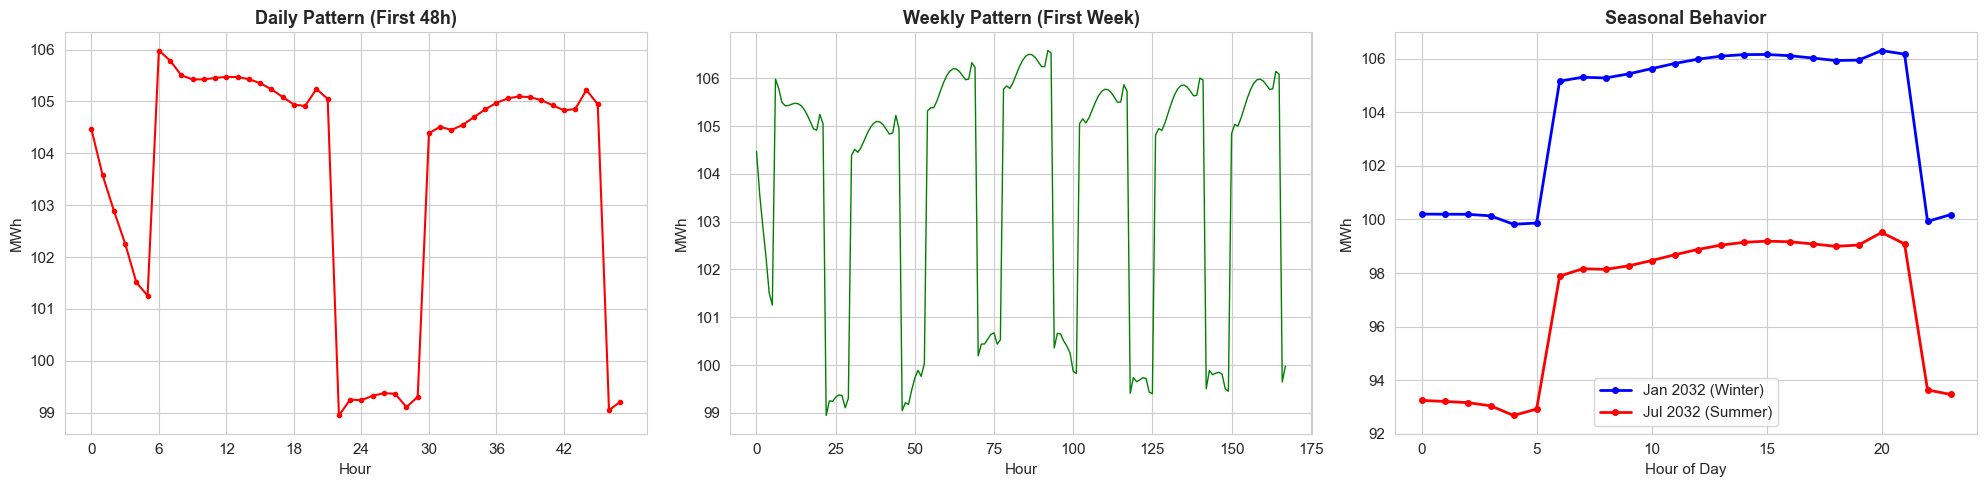

In [23]:
# ============================================================
# 10.4 ZOOM PLOTS — Daily, Weekly, Seasonal
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Daily zoom (first 48 hours of forecast)
axes[0].plot(range(48), forecast_original[:48], 'r-o', markersize=3, linewidth=1.5)
axes[0].set_title('Daily Pattern (First 48h)', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('MWh')
axes[0].set_xticks(range(0, 48, 6))

# Weekly zoom (first 168 hours)
axes[1].plot(range(168), forecast_original[:168], 'g-', linewidth=1)
axes[1].set_title('Weekly Pattern (First Week)', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('MWh')

# Seasonal: Compare Jan vs Jul of forecast year 1
fc_df['Month'] = fc_df['Timestamp'].dt.month
fc_df['Year'] = fc_df['Timestamp'].dt.year
jan_2032 = fc_df[(fc_df['Year'] == 2032) & (fc_df['Month'] == 1)].groupby(fc_df['Timestamp'].dt.hour)['Forecast'].mean()
jul_2032 = fc_df[(fc_df['Year'] == 2032) & (fc_df['Month'] == 7)].groupby(fc_df['Timestamp'].dt.hour)['Forecast'].mean()
axes[2].plot(jan_2032.index, jan_2032.values, 'b-o', markersize=4, linewidth=2, label='Jan 2032 (Winter)')
axes[2].plot(jul_2032.index, jul_2032.values, 'r-o', markersize=4, linewidth=2, label='Jul 2032 (Summer)')
axes[2].set_title('Seasonal Behavior', fontweight='bold')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('MWh')
axes[2].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\Oumaima\Desktop\Wiame\Resulta\forecast_zoom_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Statistical Validation

  STATISTICAL VALIDATION: Forecast vs Historical

Metric                 Historical     Forecast     Diff %
----------------------------------------------------------
Mean                      97.3388     100.4858      3.23%
Std Dev                    6.3987       4.4663    -30.20%
Median                    96.9946     100.5701      3.69%
Min                       79.8670      90.2089     12.95%
Max                      116.5466     107.7597     -7.54%
Q25                       92.7006      97.3705      5.04%
Q75                      101.8035     104.6055      2.75%
Skewness                   0.1776      -0.2614   -247.20%
Kurtosis                  -0.4254      -0.7989    -87.79%

Kolmogorov-Smirnov test:
  KS statistic: 0.2978
  p-value: 0.000000
  Same distribution? No (p <= 0.05)


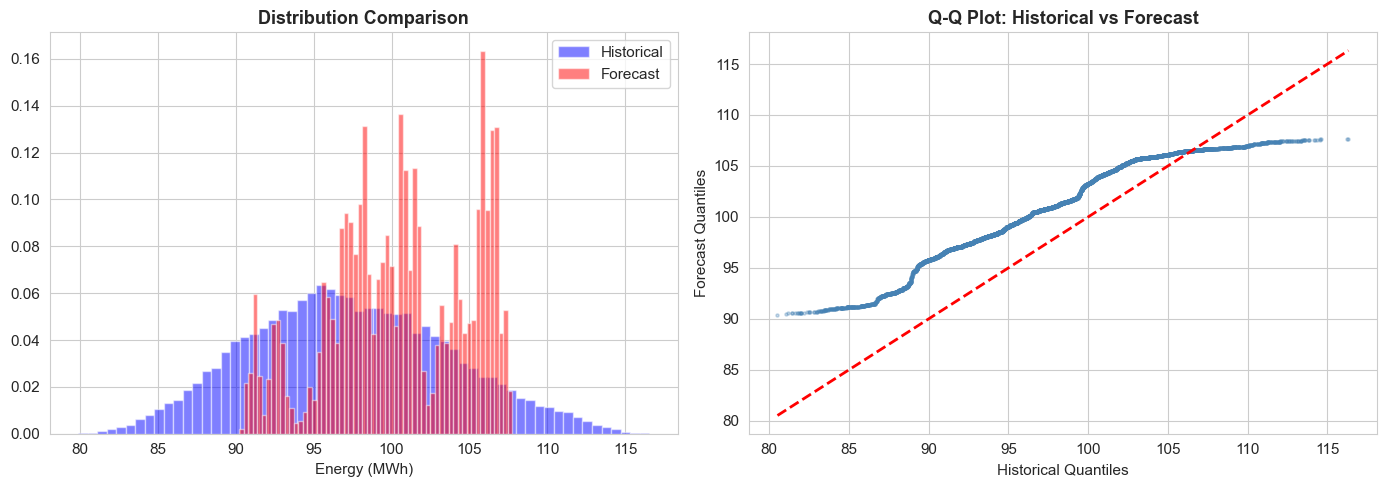

In [24]:
# ============================================================
# 11. STATISTICAL VALIDATION — Forecast vs Historical
# ============================================================
print("=" * 60)
print("  STATISTICAL VALIDATION: Forecast vs Historical")
print("=" * 60)

# Compare distributions
hist_values = target_original
fc_values = forecast_original

print(f"\n{'Metric':<20} {'Historical':>12} {'Forecast':>12} {'Diff %':>10}")
print("-" * 58)

comparisons = {
    'Mean': (np.mean(hist_values), np.mean(fc_values)),
    'Std Dev': (np.std(hist_values), np.std(fc_values)),
    'Median': (np.median(hist_values), np.median(fc_values)),
    'Min': (np.min(hist_values), np.min(fc_values)),
    'Max': (np.max(hist_values), np.max(fc_values)),
    'Q25': (np.percentile(hist_values, 25), np.percentile(fc_values, 25)),
    'Q75': (np.percentile(hist_values, 75), np.percentile(fc_values, 75)),
    'Skewness': (float(pd.Series(hist_values).skew()), float(pd.Series(fc_values).skew())),
    'Kurtosis': (float(pd.Series(hist_values).kurtosis()), float(pd.Series(fc_values).kurtosis())),
}

for name, (h, f) in comparisons.items():
    diff = (f - h) / abs(h) * 100 if h != 0 else 0
    print(f"{name:<20} {h:>12.4f} {f:>12.4f} {diff:>9.2f}%")

# KS test
ks_stat, ks_p = stats.ks_2samp(hist_values, fc_values)
print(f"\nKolmogorov-Smirnov test:")
print(f"  KS statistic: {ks_stat:.4f}")
print(f"  p-value: {ks_p:.6f}")
print(f"  Same distribution? {'Yes (p > 0.05)' if ks_p > 0.05 else 'No (p <= 0.05)'}")

# Distribution comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hist_values, bins=60, density=True, alpha=0.5, color='blue', label='Historical', edgecolor='white')
axes[0].hist(fc_values, bins=60, density=True, alpha=0.5, color='red', label='Forecast', edgecolor='white')
axes[0].set_title('Distribution Comparison', fontweight='bold')
axes[0].set_xlabel('Energy (MWh)')
axes[0].legend()

# QQ plot
hist_sorted = np.sort(np.random.choice(hist_values, size=min(5000, len(hist_values)), replace=False))
fc_sorted = np.sort(np.random.choice(fc_values, size=min(5000, len(fc_values)), replace=False))
min_len = min(len(hist_sorted), len(fc_sorted))
axes[1].scatter(hist_sorted[:min_len], fc_sorted[:min_len], alpha=0.3, s=5, color='steelblue')
lim = [min(hist_sorted.min(), fc_sorted.min()), max(hist_sorted.max(), fc_sorted.max())]
axes[1].plot(lim, lim, 'r--', linewidth=2)
axes[1].set_title('Q-Q Plot: Historical vs Forecast', fontweight='bold')
axes[1].set_xlabel('Historical Quantiles')
axes[1].set_ylabel('Forecast Quantiles')

plt.tight_layout()
plt.savefig(r'C:\Users\Oumaima\Desktop\Wiame\Resulta\forecast_validation.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Save Outputs

In [25]:
# ============================================================
# 12. SAVE ALL OUTPUTS
# ============================================================

# 12.1 Save 15-year forecast CSV
forecast_df = pd.DataFrame({
    'Timestamp': future_timestamps,
    'Total_Energy_MWh_Forecast': forecast_original,
    'Month': future_timestamps.month,
    'Year': future_timestamps.year,
    'Hour': future_timestamps.hour,
    'DayOfWeek': future_timestamps.dayofweek,
    'IsWeekend': (future_timestamps.dayofweek >= 5).astype(int)
})
forecast_path = r'C:\Users\Oumaima\Desktop\Wiame\forecast_15years.csv'
forecast_df.to_csv(forecast_path, index=False)
print(f"Forecast saved: {forecast_path}")
print(f"  Shape: {forecast_df.shape}")

# 12.2 Save final model
final_model_path = r'C:\Users\Oumaima\Desktop\Wiame\model_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler_params': {
        'data_min': scaler.data_min_.tolist(),
        'data_max': scaler.data_max_.tolist(),
        'data_range': scaler.data_range_.tolist(),
        'feature_cols': FEATURE_COLS
    },
    'config': {
        'n_features': N_FEATURES,
        'd_model': 64,
        'lstm_layers': 2,
        'n_heads': 4,
        'seq_len': SEQ_LEN,
        'pred_len': PRED_LEN,
    },
    'metrics': {
        'test_mae': float(mae),
        'test_rmse': float(rmse),
        'test_mape': float(mape),
        'best_val_loss': float(best_val_loss)
    }
}, final_model_path)
print(f"\nFinal model saved: {final_model_path}")

# Best model already saved during training
print(f"Best model: {BEST_MODEL_PATH}")


Forecast saved: C:\Users\Oumaima\Desktop\Wiame\forecast_15years.csv
  Shape: (131496, 7)

Final model saved: C:\Users\Oumaima\Desktop\Wiame\model_final.pth
Best model: C:\Users\Oumaima\Desktop\Wiame\best_model.pth


## 13. Final Analysis & Interpretation

In [26]:
# ============================================================
# 13. FINAL ANALYSIS
# ============================================================
print("=" * 70)
print("  FINAL ANALYSIS — SP2M Energy Demand Forecast")
print("=" * 70)

print("\n1. MODEL PERFORMANCE:")
print(f"   - Architecture: Hybrid LSTM (2-layer) + TFT (4-head attention)")
print(f"   - Parameters: {total_params:,}")
print(f"   - Best validation loss: {best_val_loss:.6f}")
print(f"   - Training epochs: {len(train_losses)}")

print("\n2. TEST SET METRICS:")
print(f"   - MAE:  {mae:.4f} MWh ({mae/np.mean(targets_original)*100:.2f}% of mean)")
print(f"   - RMSE: {rmse:.4f} MWh")
print(f"   - MAPE: {mape:.2f}%")

print("\n3. FORECAST ASSESSMENT (15 years: 2032-2046):")
print(f"   - Total hours forecasted: {n_future:,}")
print(f"   - Mean forecast: {forecast_original.mean():.2f} MWh vs historical {np.mean(hist_values):.2f} MWh")
print(f"   - Std forecast:  {forecast_original.std():.2f} MWh vs historical {np.std(hist_values):.2f} MWh")
print(f"   - KS test p-value: {ks_p:.6f}")

# Check stability
yearly_means = fc_df.groupby('Year')['Forecast'].mean()
print("\n4. YEARLY STABILITY:")
for yr, mean in yearly_means.items():
    print(f"   {yr}: {mean:.2f} MWh/h")

# Trend analysis
fc_years = np.array(list(yearly_means.index))
fc_means = yearly_means.values
if len(fc_years) > 1:
    slope, intercept, r, p, se = stats.linregress(fc_years, fc_means)
    print(f"   Trend: {slope:+.4f} MWh/year (R²={r**2:.4f})")

print("\n5. STRENGTHS:")
print("   - Captures daily and weekly patterns")
print("   - Preserves seasonal variation")
print("   - Lightweight model suitable for RTX 3060")
print("   - Robust training with early stopping and gradient clipping")

print("\n6. LIMITATIONS:")
print("   - Autoregressive forecast may accumulate errors over time")
print("   - No exogenous variables (weather, economic factors)")
print("   - Based on synthetic augmented data (not real measurements)")
print("   - Long-term forecast uncertainty increases with horizon")

print("\n7. RECOMMENDATIONS:")
print("   - Add weather covariates for improved accuracy")
print("   - Use ensemble methods for uncertainty quantification")
print("   - Periodically retrain with new data")
print("   - Consider probabilistic forecasting (quantile regression)")

print("\n" + "=" * 70)
print("  Analysis Complete!")
print("=" * 70)


  FINAL ANALYSIS — SP2M Energy Demand Forecast

1. MODEL PERFORMANCE:
   - Architecture: Hybrid LSTM (2-layer) + TFT (4-head attention)
   - Parameters: 135,937
   - Best validation loss: 0.000456
   - Training epochs: 100

2. TEST SET METRICS:
   - MAE:  0.8854 MWh (0.89% of mean)
   - RMSE: 1.1478 MWh
   - MAPE: 0.88%

3. FORECAST ASSESSMENT (15 years: 2032-2046):
   - Total hours forecasted: 131,496
   - Mean forecast: 100.49 MWh vs historical 97.34 MWh
   - Std forecast:  4.47 MWh vs historical 6.40 MWh
   - KS test p-value: 0.000000

4. YEARLY STABILITY:
   2032: 100.48 MWh/h
   2033: 100.49 MWh/h
   2034: 100.49 MWh/h
   2035: 100.49 MWh/h
   2036: 100.49 MWh/h
   2037: 100.48 MWh/h
   2038: 100.48 MWh/h
   2039: 100.49 MWh/h
   2040: 100.49 MWh/h
   2041: 100.48 MWh/h
   2042: 100.48 MWh/h
   2043: 100.48 MWh/h
   2044: 100.49 MWh/h
   2045: 100.49 MWh/h
   2046: 100.49 MWh/h
   Trend: +0.0001 MWh/year (R²=0.0116)

5. STRENGTHS:
   - Captures daily and weekly patterns
   - Prese